In [1]:
# locate the root folder
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

# import time
# import math
# from typing import Tuple, Optional, List

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.nn.functional as F
from models.stylegan2_mlp import MappingNetwork, MappingNetwork_cs, MappingNetwork_cs_sparsity, EqualizedLinear
import matplotlib.pyplot as plt

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive


In [2]:
def L1_lasso_output_regularization(output, reg_type='row'):
    if reg_type == 'row':
        return torch.sum(torch.abs(output).sum(dim=2))
    elif reg_type == 'column':
        return torch.sum(torch.abs(output).sum(dim=1))
    elif reg_type == 'element':
        return torch.sum(torch.abs(output))
    else:
        raise ValueError(f"Invalid regularization type: '{reg_type}'.")

def L1_lasso_weight_regularization(model, network='net_s', reg_type='all'):
    """
    Apply L1 regularization on the specified layers of either `net_s` or `net_c` in the model.

    Args:
        model (MappingNetwork_cs_sparsity): The model with the network to regularize.
        network (str): The network to apply Lasso regularization ('net_s' or 'net_c').
        reg_type (str): Type of weight regularization ('all' or 'last').
            - 'all': Applies Lasso to all EqualizedLinear layers in the specified network.
            - 'last': Applies Lasso only to the last EqualizedLinear layer in the specified network.

    Returns:
        torch.Tensor: Computed L1 regularization penalty for the selected layers.
    """
    lasso_weight_penalty = 0.0
    
    # Select the target network based on the network argument
    target_network = getattr(model, network, None)
    if target_network is None:
        raise ValueError(f"Invalid network '{network}'. Use 'net_s' or 'net_c'.")

    # Get layers of the selected network
    layers = list(target_network.children())

    if reg_type == 'all':
        # Apply Lasso to all EqualizedLinear layers in the target network
        for layer in layers:
            if isinstance(layer[0], EqualizedLinear):
                lasso_weight_penalty += torch.sum(torch.abs(layer[0].weight.weight))  # Access raw weight tensor
    elif reg_type == 'last':
        # Apply Lasso only to the last EqualizedLinear layer in the target network
        last_layer = layers[-1][0]
        if isinstance(last_layer, EqualizedLinear):
            lasso_weight_penalty += torch.sum(torch.abs(last_layer.weight.weight))  # Access raw weight tensor
    else:
        raise ValueError(f"Invalid reg_type '{reg_type}'. Use 'all' or 'last'.")

    return lasso_weight_penalty


def calculate_latent_loss(latent_bg_s, latent_t_s, latent_bg, latent_t, latent_bg_target, latent_t_target, 
                          lasso_output_lambda=0.01, lasso_weight_lambda=0.01, model=None, 
                          lasso_output_type='row', lasso_weight_type='all', network='net_s'):
    """
    Calculate total loss, including L1 regularization for output and weights.

    Args:
        latent_bg_s: Background latent tensor.
        latent_t_s: Target latent tensor.
        latent_bg: Background tensor.
        latent_t: Target tensor.
        latent_bg_target: Target tensor for background.
        latent_t_target: Target tensor for output.
        lasso_output_lambda: Weight for output L1 regularization.
        lasso_weight_lambda: Weight for weight L1 regularization.
        model: The model on which to apply regularization.
        lasso_output_type: Type of L1 regularization for output ('row', 'column', 'element').
        lasso_weight_type: Type of L1 regularization for weights ('all', 'last').
        network: Specifies 'net_s' or 'net_c' for weight regularization.

    Returns:
        total_loss: Computed total loss.
        loss_dict: Dictionary with individual loss components.
    """
    loss_silent_bg = F.mse_loss(latent_bg_s, torch.zeros_like(latent_bg_s))
    loss_distance_bg = F.mse_loss(latent_bg, latent_bg_target)
    loss_distance_t = F.mse_loss(latent_t, latent_t_target)
    
    lasso_output_loss = lasso_output_lambda * L1_lasso_output_regularization(latent_t_s, reg_type=lasso_output_type)
    lasso_weight_loss = (
        lasso_weight_lambda * L1_lasso_weight_regularization(model, network=network, reg_type=lasso_weight_type) 
        if model else 0.0
    )
    
    total_loss = loss_silent_bg + loss_distance_bg + loss_distance_t + lasso_output_loss + lasso_weight_loss
    return total_loss, {
        'loss_silent_bg': loss_silent_bg.item(),
        'loss_distance_bg': loss_distance_bg.item(),
        'loss_distance_t': loss_distance_t.item(),
        'lasso_output_loss': lasso_output_loss.item(),
        'lasso_weight_loss': lasso_weight_loss.item(),
        'total_loss': total_loss.item()
    }


class Options:
    def __init__(self, batch_size=4, style_dim=18, latent_dim=512, n_layers_mlp=8, zero_out_type='hard', zero_threshold=0.01,
                 lasso_output_lambda=0.1, lasso_weight_lambda=0.01, lasso_output_type='row', lasso_weight_type='all'):
        self.batch_size = batch_size
        self.style_dim = style_dim
        self.latent_dim = latent_dim
        self.n_layers_mlp = n_layers_mlp
        self.zero_out_type = zero_out_type
        self.zero_threshold = zero_threshold
        self.lasso_output_lambda = lasso_output_lambda
        self.lasso_weight_lambda = lasso_weight_lambda
        self.lasso_output_type = lasso_output_type
        self.lasso_weight_type = lasso_weight_type


def calculate_weight_sparsity(model, network='net_s', reg_type='all', zero_threshold=0.0):
    zero_count, total_count = 0, 0
    target_network = getattr(model, network, None)
    if target_network is None:
        raise ValueError(f"Invalid network '{network}'. Use 'net_s' or 'net_c'.")

    layers = list(target_network.children())
    
    if reg_type == 'all':
        for layer in layers:
            if isinstance(layer[0], EqualizedLinear):
                weights = layer[0].weight.weight
                zero_count += (weights.abs() <= zero_threshold).sum().item()
                total_count += weights.numel()
    elif reg_type == 'last':
        last_layer = layers[-1][0]
        if isinstance(last_layer, EqualizedLinear):
            weights = last_layer.weight.weight
            zero_count += (weights.abs() <= zero_threshold).sum().item()
            total_count += weights.numel()
    else:
        raise ValueError(f"Invalid reg_type '{reg_type}'. Use 'all' or 'last'.")

    sparsity = zero_count / total_count if total_count > 0 else 0
    return sparsity, zero_count, total_count

def calculate_output_sparsity(output, zero_threshold=0.0):
    """
    Calculate sparsity of output activations.

    Args:
        output (torch.Tensor): The output tensor for which sparsity is calculated.
        zero_threshold (float): Threshold below which values are considered zero.

    Returns:
        sparsity (float): The fraction of elements that are effectively zero.
        zero_count (int): Number of zero-valued elements.
        total_count (int): Total number of elements.
    """
    zero_count = (output.abs() <= zero_threshold).sum().item()   #If zero_threshold=0.0, only values that are exactly zero will be counted as sparse. For any other zero_threshold > 0, values with absolute magnitude less than or equal to the threshold will be considered sparse
    total_count = output.numel()
    sparsity = zero_count / total_count if total_count > 0 else 0
    return sparsity, zero_count, total_count


def compare_lasso_weight_effects(lasso_weight_values, num_epochs=100, learning_rate=0.01, lasso_weight_type='all', zero_threshold=0.0, lasso_output_lambda=0.0):
    weight_sparsity_results = {}
    output_sparsity_results = {}
    loss_results = {}

    for lasso_weight_lambda in lasso_weight_values:
        opts = Options(batch_size=4, style_dim=18, latent_dim=512, n_layers_mlp=8, zero_out_type='hard', 
                       zero_threshold=zero_threshold, lasso_output_lambda=lasso_output_lambda, 
                       lasso_weight_lambda=lasso_weight_lambda, lasso_output_type='row', lasso_weight_type=lasso_weight_type)
        
        model = MappingNetwork_cs_sparsity(opts)
        latent_bg_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
        latent_t_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        weight_sparsity_tracker = []
        output_sparsity_tracker = []
        loss_tracker = []

        print(f"\nTraining with lasso_weight_lambda = {lasso_weight_lambda}, zero_threshold = {opts.zero_threshold}, lasso_output_lambda = {opts.lasso_output_lambda}")
        for epoch in range(num_epochs):
            model.train()
            
            latent_bg_c, latent_bg_s = model(latent_bg_target, zero_out_silent=False)
            latent_t_c, latent_t_s = model(latent_t_target, zero_out_silent=True)
            latent_bg = latent_bg_c
            latent_t = latent_t_c + latent_t_s

            loss, loss_dict = calculate_latent_loss(
                latent_bg_s, latent_t_s, latent_bg, latent_t, latent_bg_target, latent_t_target, 
                lasso_output_lambda=opts.lasso_output_lambda, lasso_weight_lambda=opts.lasso_weight_lambda, 
                model=model, lasso_output_type=opts.lasso_output_type, lasso_weight_type=opts.lasso_weight_type
            )
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track weight sparsity
            weight_sparsity, weight_zero_count, weight_total_count = calculate_weight_sparsity(model, zero_threshold=1e-6)
            weight_sparsity_tracker.append(weight_sparsity)

            # Track output sparsity for latent_t_s
            output_sparsity, output_zero_count, output_total_count = calculate_output_sparsity(latent_t_s, zero_threshold=0.0)
            output_sparsity_tracker.append(output_sparsity)

            # Track total loss
            loss_tracker.append(loss_dict['total_loss'])
            if epoch % (num_epochs / 10) == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}], Total Loss: {loss_dict['total_loss']:.4f}, Weight Sparsity: {weight_sparsity:.4f} ({weight_zero_count} of {weight_total_count}), Output Sparsity: {output_sparsity:.4f} ({output_zero_count} of {output_total_count})")

        weight_sparsity_results[lasso_weight_lambda] = weight_sparsity_tracker
        output_sparsity_results[lasso_weight_lambda] = output_sparsity_tracker
        loss_results[lasso_weight_lambda] = loss_tracker

    # Plot weight sparsity for all lasso_weight_lambda values
    plt.figure(figsize=(10, 6))
    for lasso_weight_lambda, sparsity_tracker in weight_sparsity_results.items():
        plt.plot(sparsity_tracker, label=f"lasso_weight_lambda={lasso_weight_lambda}")
    plt.title("Weight Sparsity Over Epochs for Different Lasso Weight Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Weight Sparsity")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot output sparsity for all lasso_weight_lambda values
    plt.figure(figsize=(10, 6))
    for lasso_weight_lambda, sparsity_tracker in output_sparsity_results.items():
        plt.plot(sparsity_tracker, label=f"lasso_weight_lambda={lasso_weight_lambda}")
    plt.title("Output Sparsity Over Epochs for Different Lasso Weight Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Output Sparsity")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot total loss for all lasso_weight_lambda values
    plt.figure(figsize=(10, 6))
    for lasso_weight_lambda, loss_tracker in loss_results.items():
        plt.plot(loss_tracker, label=f"lasso_weight_lambda={lasso_weight_lambda}")
    plt.title("Total Loss Over Epochs for Different Lasso Weight Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()






Training with lasso_weight_lambda = 0.0, zero_threshold = 0.0, lasso_output_lambda = 0.0
Epoch [1/1000], Total Loss: 2.0056, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [101/1000], Total Loss: 0.5320, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [201/1000], Total Loss: 0.2282, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [301/1000], Total Loss: 0.1013, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [401/1000], Total Loss: 0.0488, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [501/1000], Total Loss: 0.0208, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [601/1000], Total Loss: 0.0109, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [701/1000], Total Loss: 0.0086, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0000 (0 of

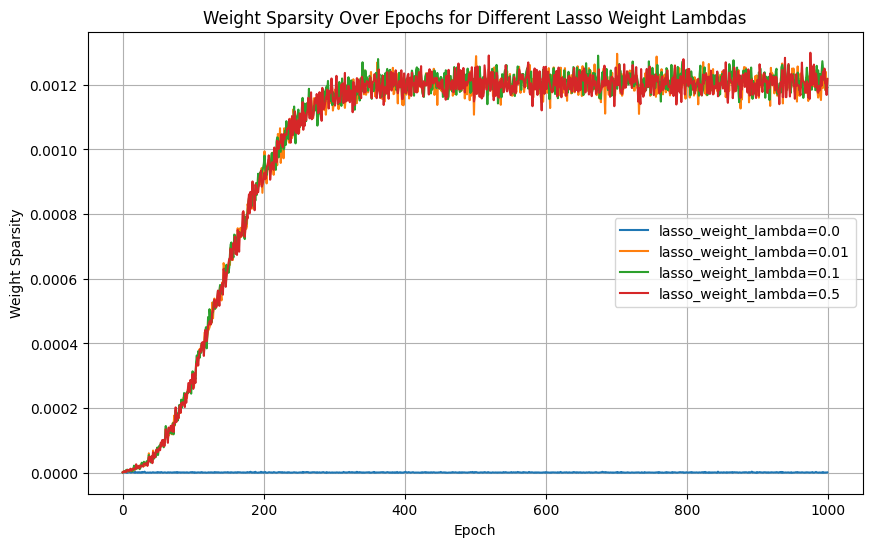

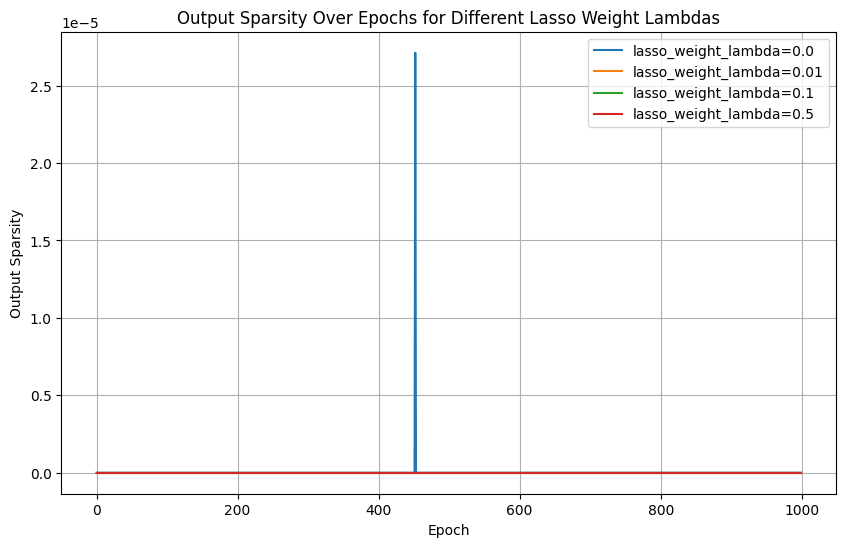

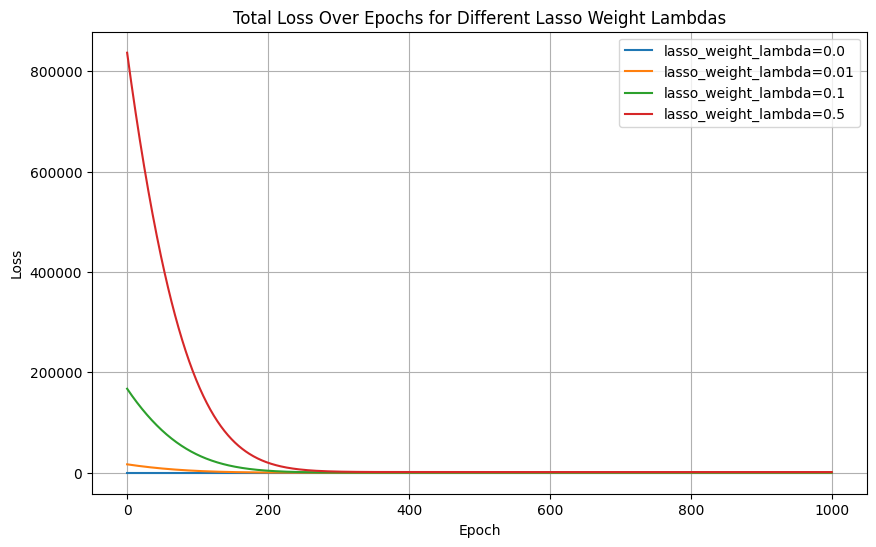

In [3]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.0, lasso_output_lambda=0.0)


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.0, lasso_output_lambda = 0.0
Epoch [1/1000], Total Loss: 2.0072, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [101/1000], Total Loss: 0.5420, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [201/1000], Total Loss: 0.2533, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [301/1000], Total Loss: 0.1189, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [401/1000], Total Loss: 0.0498, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [501/1000], Total Loss: 0.0348, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [601/1000], Total Loss: 0.0095, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [701/1000], Total Loss: 0.0070, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of

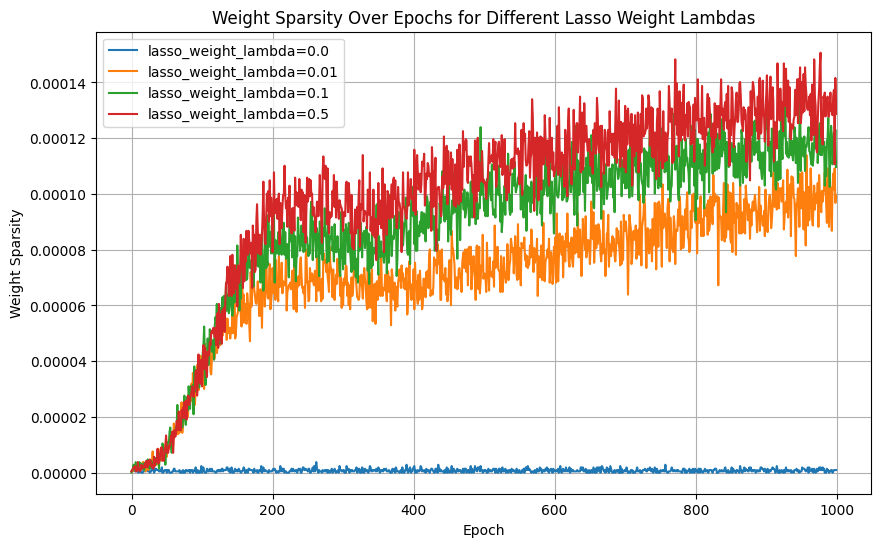

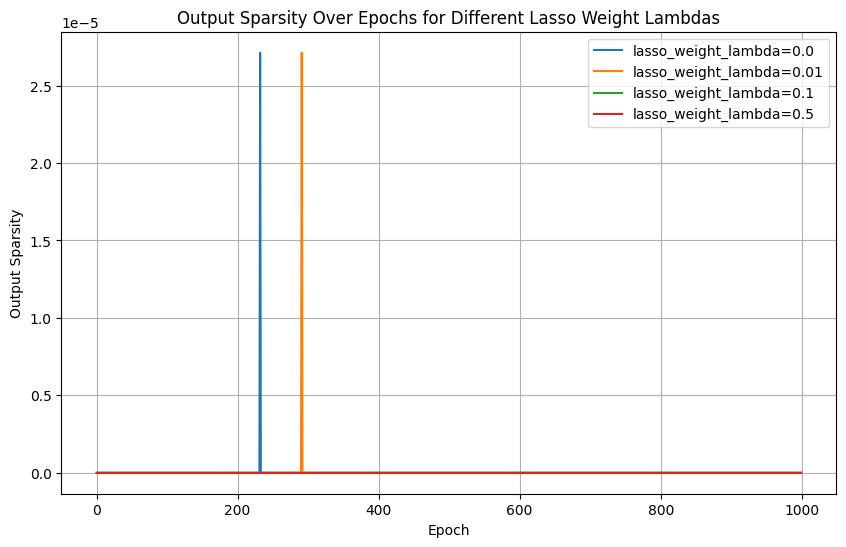

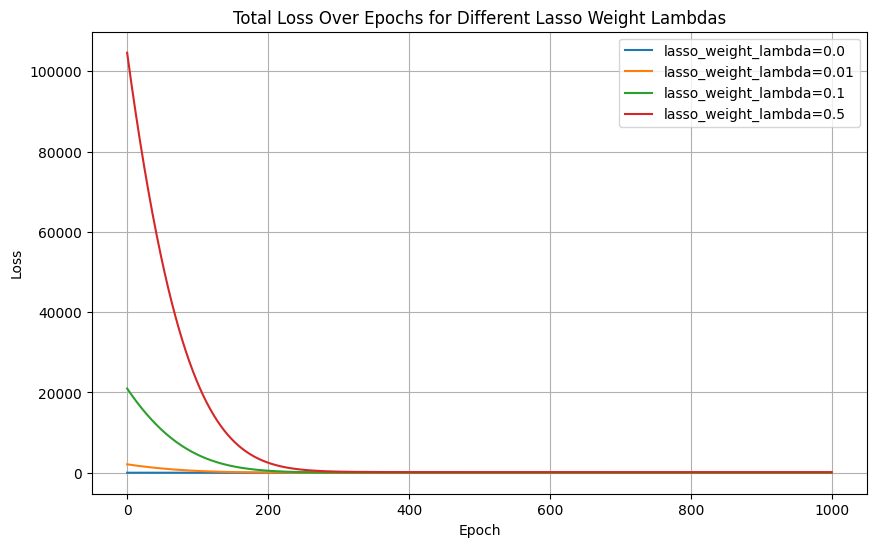

In [4]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='last', zero_threshold=0.0, lasso_output_lambda=0.0)


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.0, lasso_output_lambda = 0.0
Epoch [1/1000], Total Loss: 2.0185, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [101/1000], Total Loss: 0.5363, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [201/1000], Total Loss: 0.2571, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [301/1000], Total Loss: 0.1091, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [401/1000], Total Loss: 0.0692, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [501/1000], Total Loss: 0.0235, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [601/1000], Total Loss: 0.0175, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [701/1000], Total Loss: 0.0108, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of

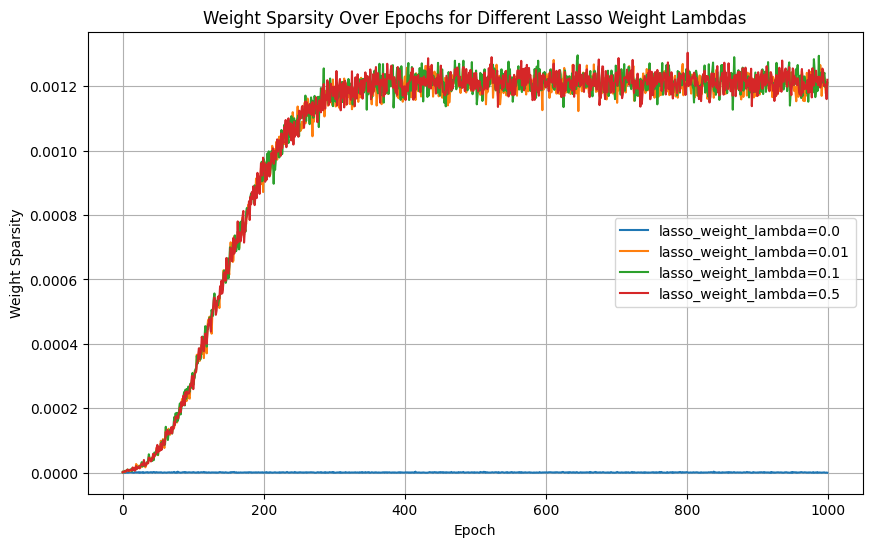

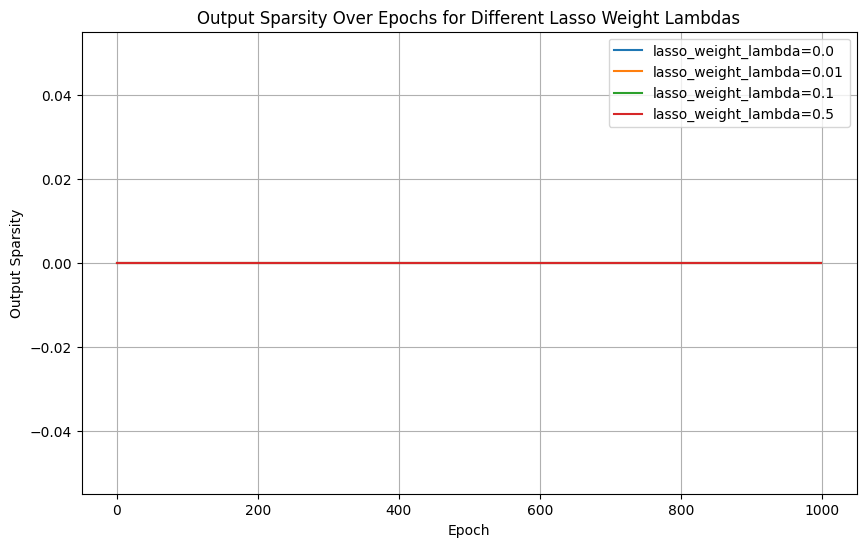

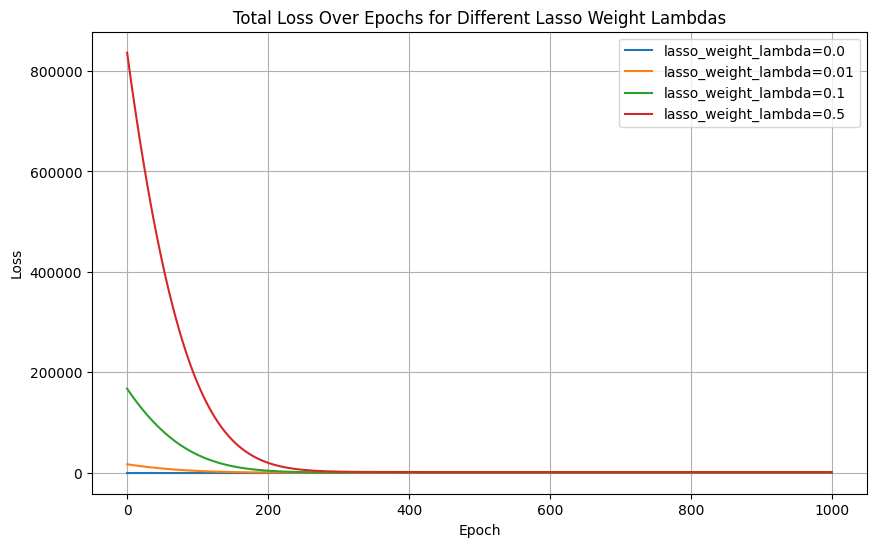

In [5]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.0, lasso_output_lambda=0.0)

### lasso wight + zero_out 0.01


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.01, lasso_output_lambda = 0.0
Epoch [1/1000], Total Loss: 2.0018, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.6398 (23584 of 36864)
Epoch [101/1000], Total Loss: 0.5208, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0107 (396 of 36864)
Epoch [201/1000], Total Loss: 0.2165, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0127 (468 of 36864)
Epoch [301/1000], Total Loss: 0.0950, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0129 (474 of 36864)
Epoch [401/1000], Total Loss: 0.0506, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0149 (548 of 36864)
Epoch [501/1000], Total Loss: 0.0190, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0168 (619 of 36864)
Epoch [601/1000], Total Loss: 0.0130, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0180 (663 of 36864)
Epoch [701/1000], Total Loss: 0.0088, Weight Sparsity: 0.0000 (4 of 2097152), Output Spars

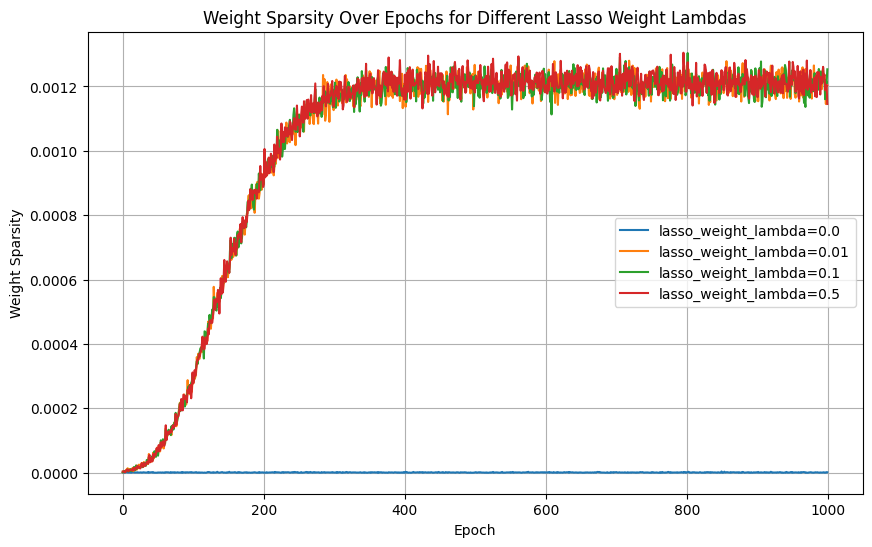

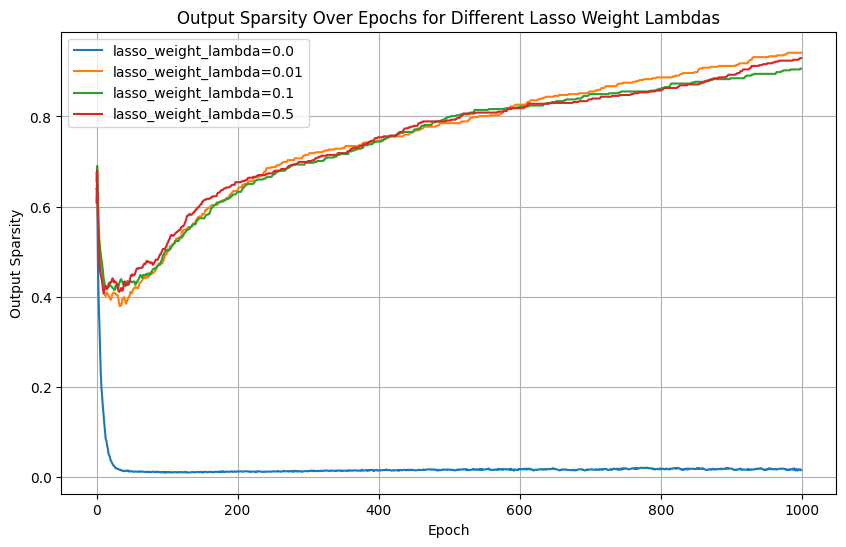

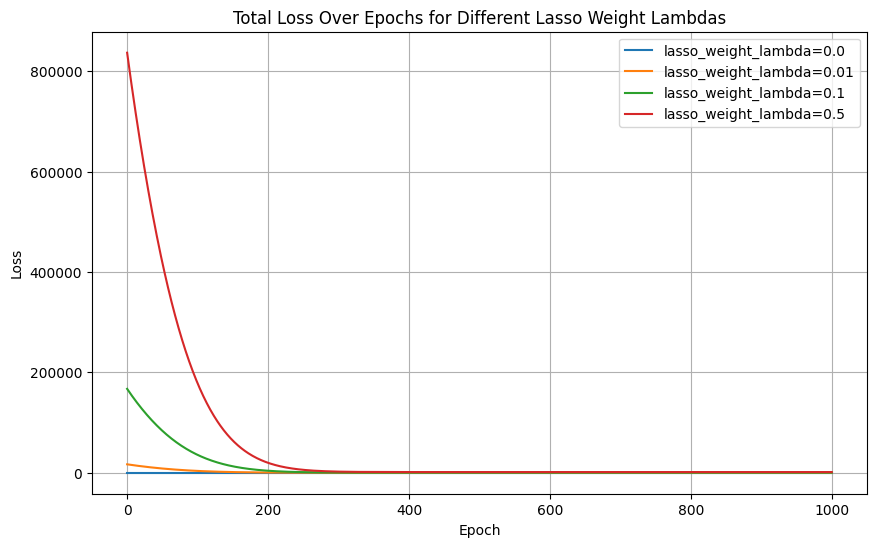

In [6]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.01, lasso_output_lambda=0.0)

### lasso wight + zero_out 0.001


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.001, lasso_output_lambda = 0.0
Epoch [1/1000], Total Loss: 2.0012, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0974 (3592 of 36864)
Epoch [101/1000], Total Loss: 0.5211, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0009 (35 of 36864)
Epoch [201/1000], Total Loss: 0.2402, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0011 (40 of 36864)
Epoch [301/1000], Total Loss: 0.1177, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0011 (41 of 36864)
Epoch [401/1000], Total Loss: 0.0492, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0014 (51 of 36864)
Epoch [501/1000], Total Loss: 0.0223, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0014 (51 of 36864)
Epoch [601/1000], Total Loss: 0.0121, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0015 (57 of 36864)
Epoch [701/1000], Total Loss: 0.0118, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0

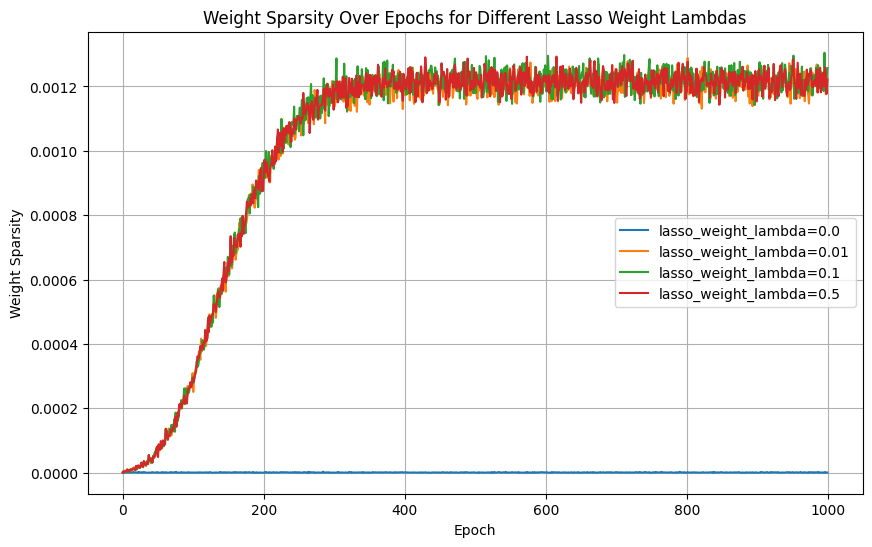

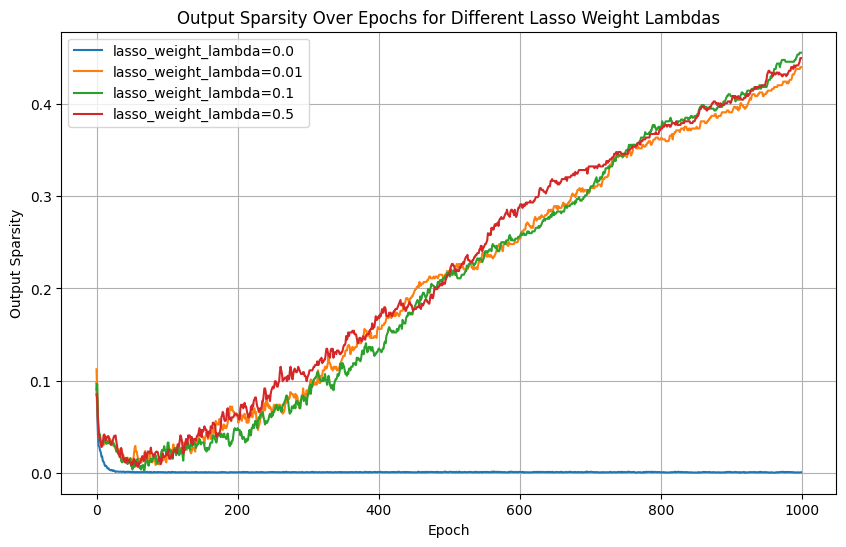

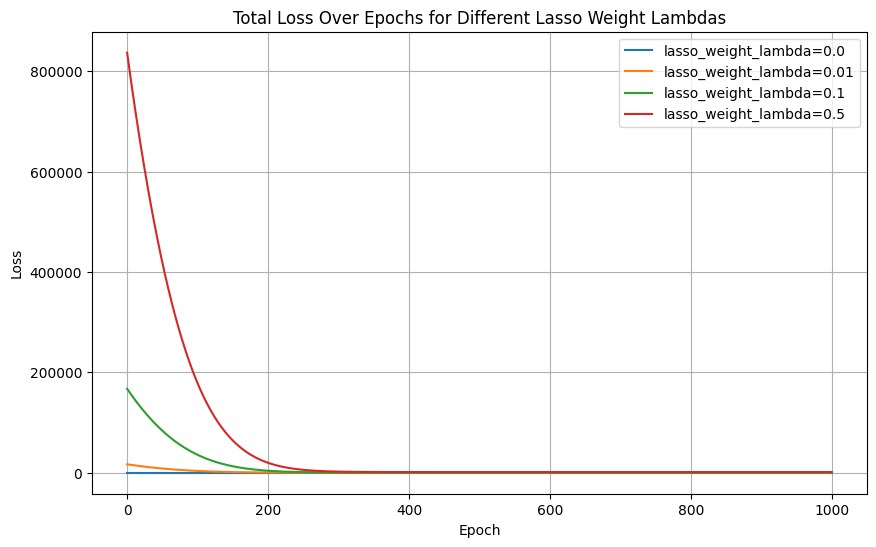

In [7]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.001, lasso_output_lambda=0.0)

### lasso wight + lasso output 0.01


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.0, lasso_output_lambda = 0.01
Epoch [1/1000], Total Loss: 6.6659, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [101/1000], Total Loss: 1.1807, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [201/1000], Total Loss: 0.8473, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [301/1000], Total Loss: 0.6742, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [401/1000], Total Loss: 0.5677, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [501/1000], Total Loss: 0.4637, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [601/1000], Total Loss: 0.4188, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [701/1000], Total Loss: 0.4140, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 o

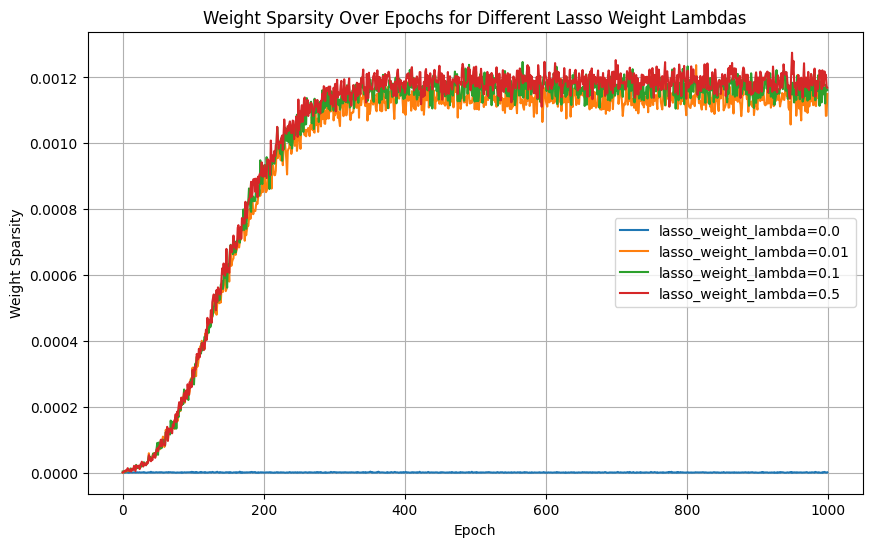

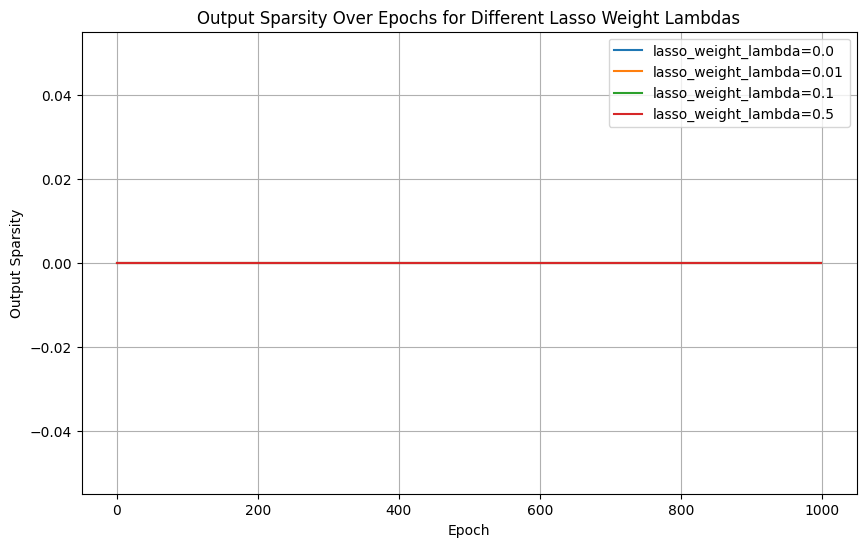

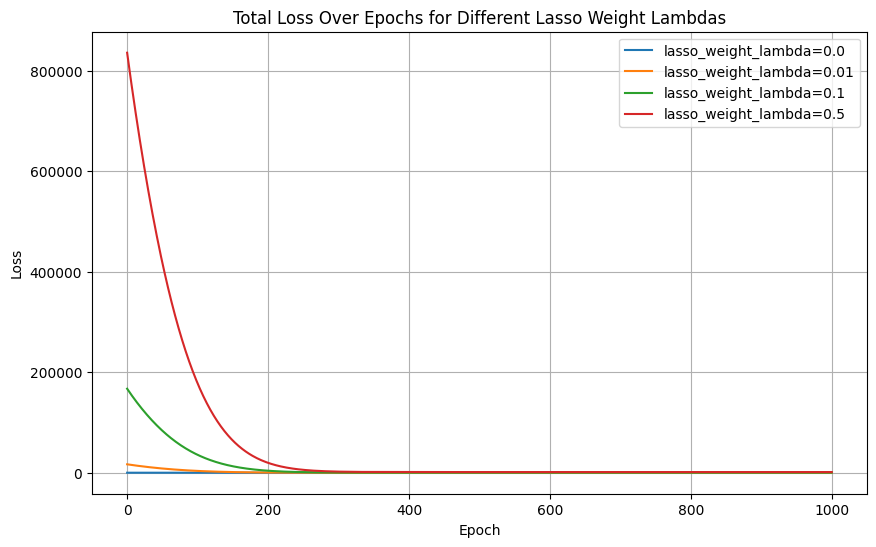

In [8]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.0, lasso_output_lambda=0.01)

### lasso wight + lasso output 0.001


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.0, lasso_output_lambda = 0.001
Epoch [1/1000], Total Loss: 2.4603, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [101/1000], Total Loss: 0.9218, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [201/1000], Total Loss: 0.5902, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [301/1000], Total Loss: 0.4017, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [401/1000], Total Loss: 0.2840, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [501/1000], Total Loss: 0.2005, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [601/1000], Total Loss: 0.1563, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [701/1000], Total Loss: 0.1246, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.0000 (0 

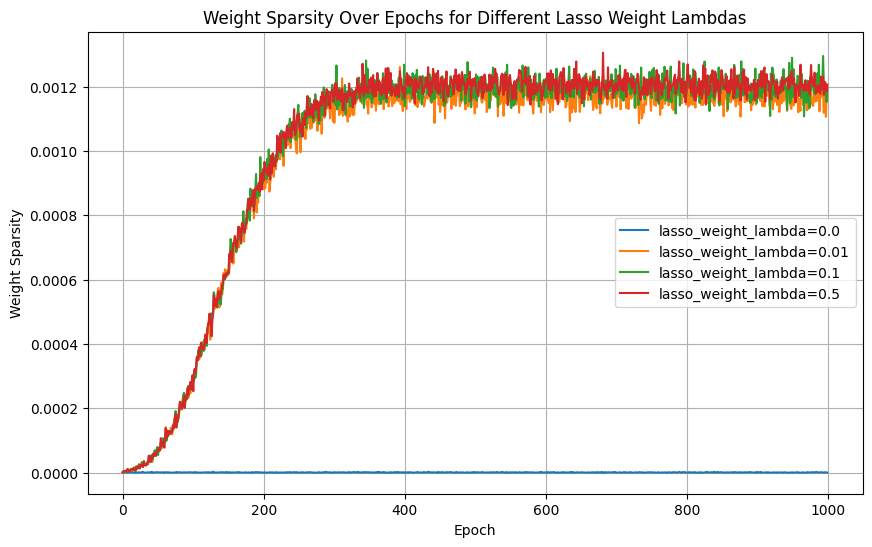

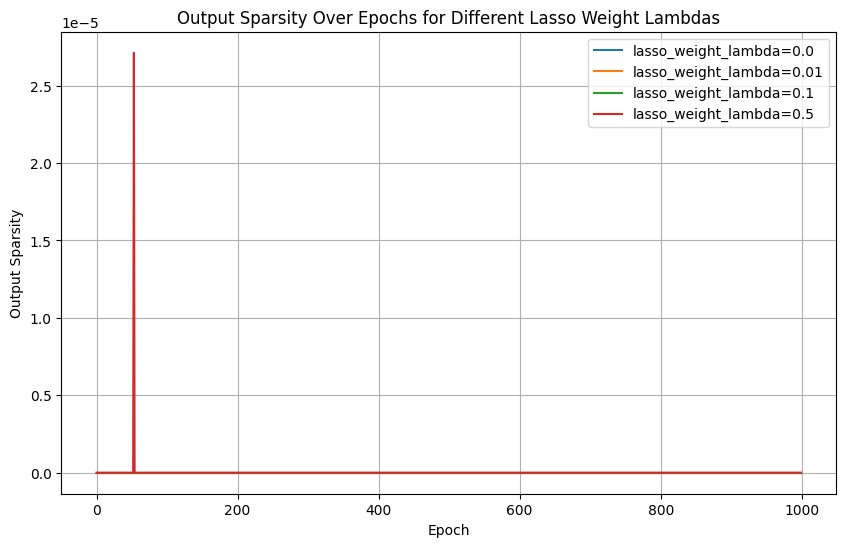

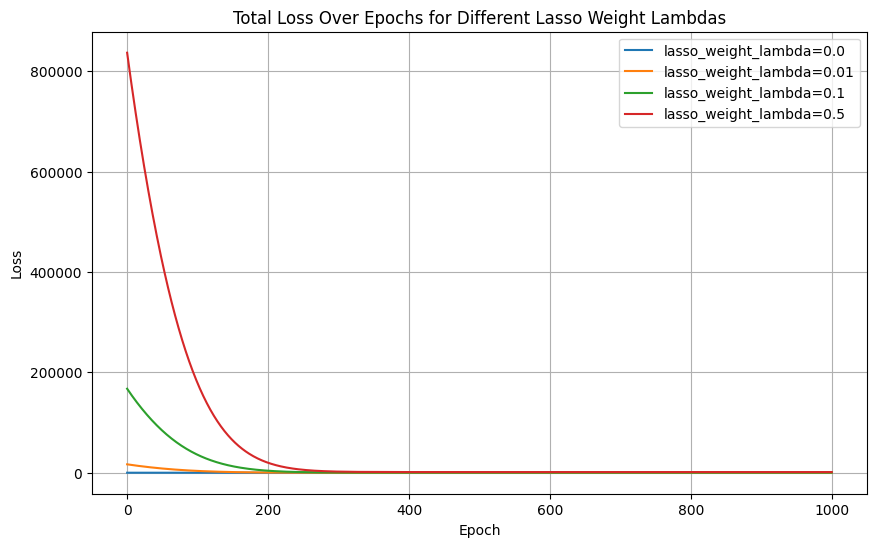

In [9]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.0, lasso_output_lambda=0.001)

### lasso wight + lasso output 0.001 + + zero_out 0.001


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.001, lasso_output_lambda = 0.001
Epoch [1/1000], Total Loss: 2.4108, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.1053 (3882 of 36864)
Epoch [101/1000], Total Loss: 0.8728, Weight Sparsity: 0.0000 (0 of 2097152), Output Sparsity: 0.8047 (29664 of 36864)
Epoch [201/1000], Total Loss: 0.5486, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.7339 (27056 of 36864)
Epoch [301/1000], Total Loss: 0.3785, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5135 (18929 of 36864)
Epoch [401/1000], Total Loss: 0.2609, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5470 (20164 of 36864)
Epoch [501/1000], Total Loss: 0.1919, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5483 (20212 of 36864)
Epoch [601/1000], Total Loss: 0.1256, Weight Sparsity: 0.0000 (5 of 2097152), Output Sparsity: 0.5750 (21196 of 36864)
Epoch [701/1000], Total Loss: 0.1010, Weight Sparsity: 0.0000 (0 of 2097152)

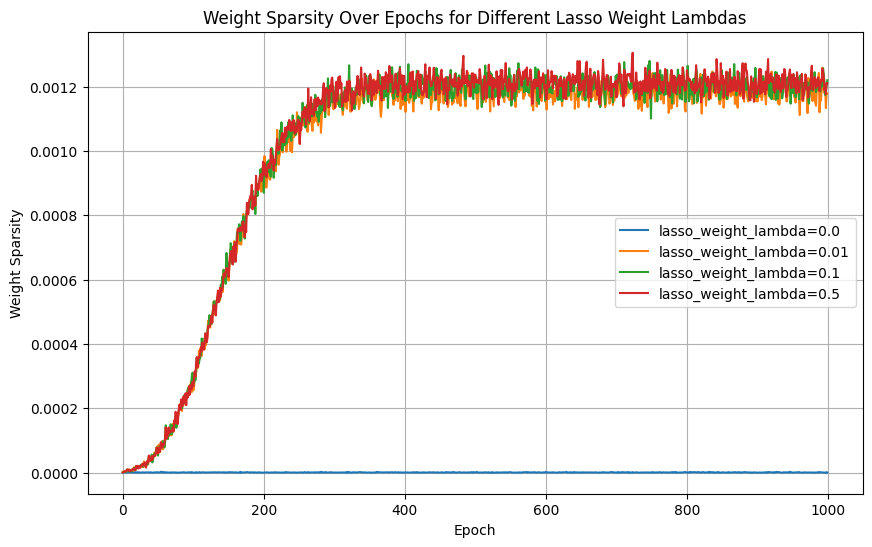

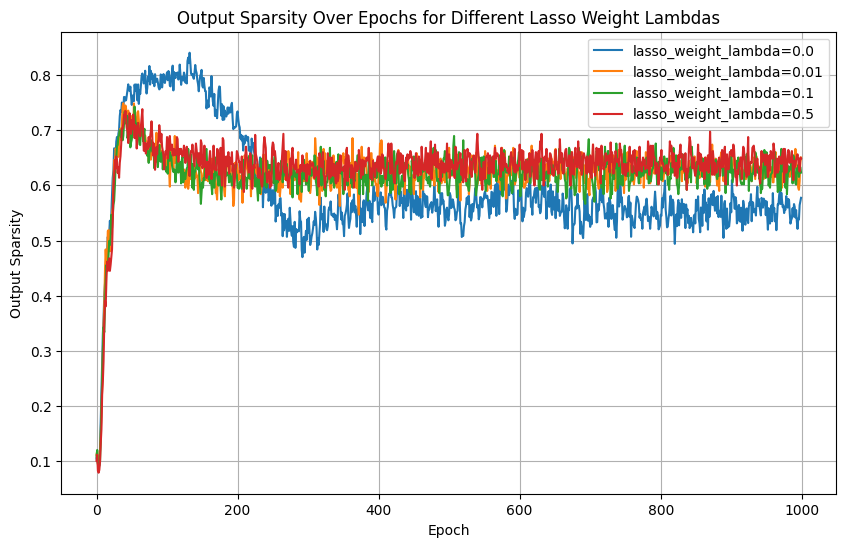

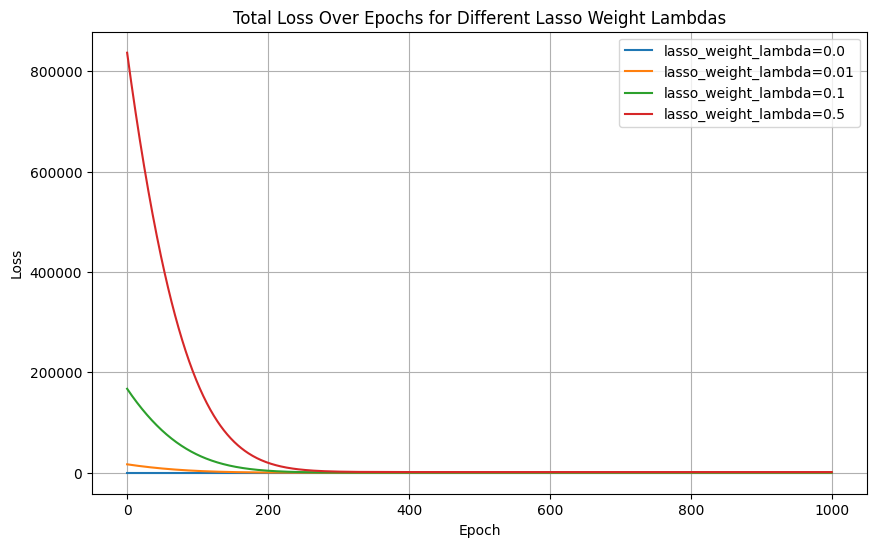

In [10]:
lasso_weight_values = [0.0, 0.01, 0.1, 0.5]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.001, lasso_output_lambda=0.001)


Training with lasso_weight_lambda = 0.0, zero_threshold = 0.001, lasso_output_lambda = 0.001
Epoch [1/1000], Total Loss: 2.4049, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0958 (3533 of 36864)
Epoch [101/1000], Total Loss: 0.8773, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.7896 (29106 of 36864)
Epoch [201/1000], Total Loss: 0.5592, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.7904 (29138 of 36864)
Epoch [301/1000], Total Loss: 0.4082, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5047 (18607 of 36864)
Epoch [401/1000], Total Loss: 0.2666, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5400 (19908 of 36864)
Epoch [501/1000], Total Loss: 0.1703, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.5615 (20698 of 36864)
Epoch [601/1000], Total Loss: 0.1368, Weight Sparsity: 0.0000 (4 of 2097152), Output Sparsity: 0.5697 (21002 of 36864)
Epoch [701/1000], Total Loss: 0.0950, Weight Sparsity: 0.0000 (2 of 2097152)

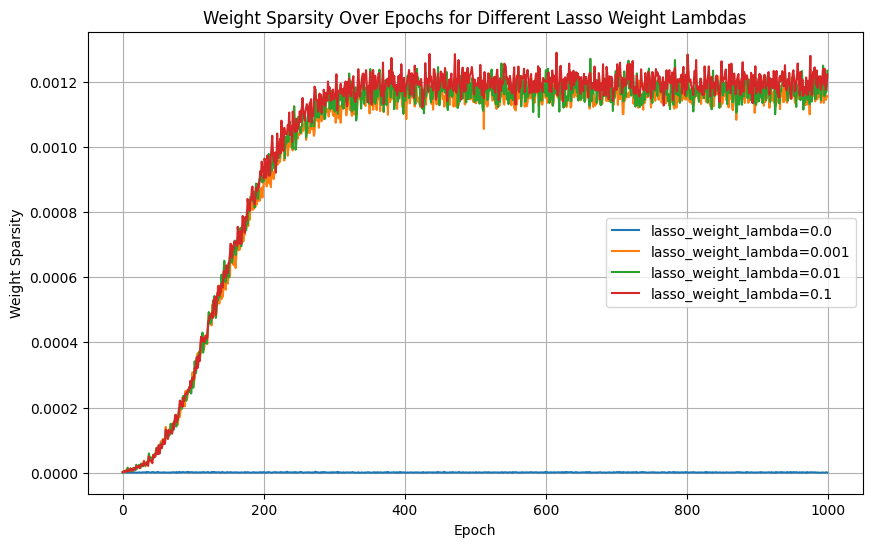

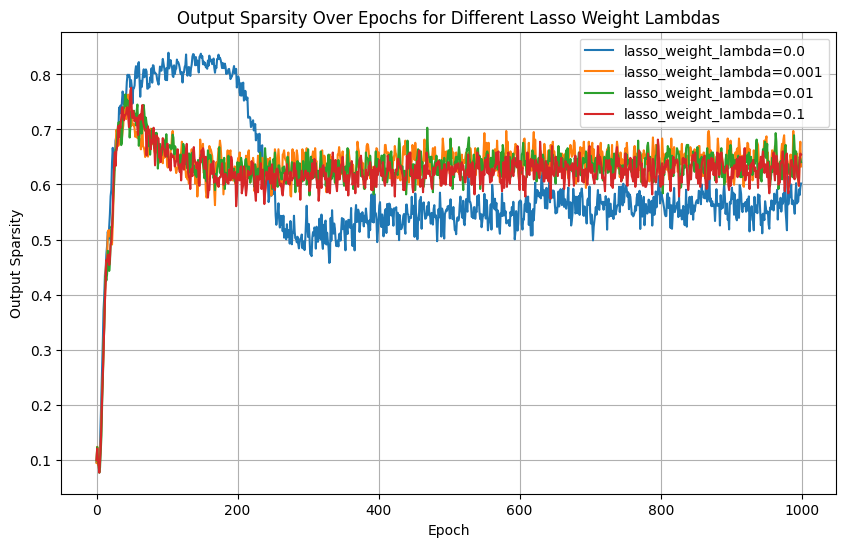

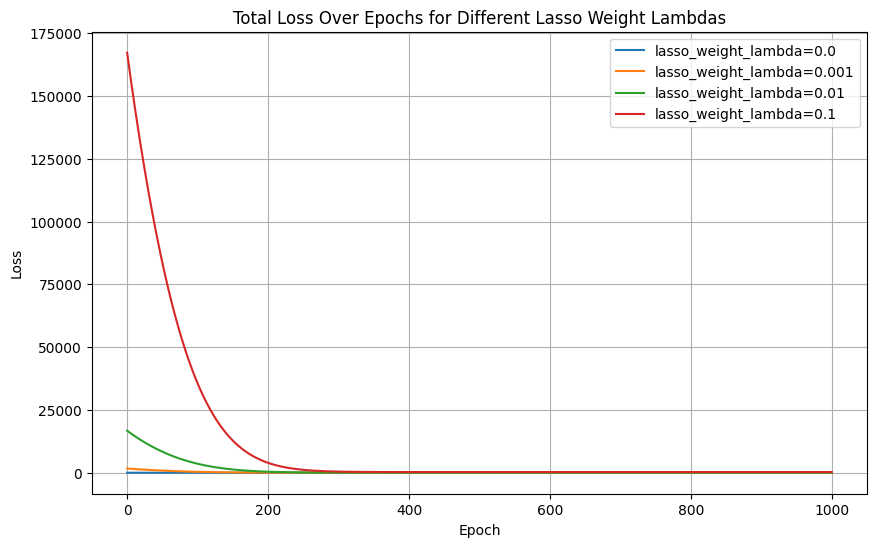

In [11]:
lasso_weight_values = [0.0, 0.001, 0.01, 0.1]
compare_lasso_weight_effects(lasso_weight_values, num_epochs=1000, lasso_weight_type='all', zero_threshold=0.001, lasso_output_lambda=0.001)